Codes to Question 1_4

Implement EKF and UKF and discuss their linearization accuracy limtis and signma point failures under strong nonlinearity.


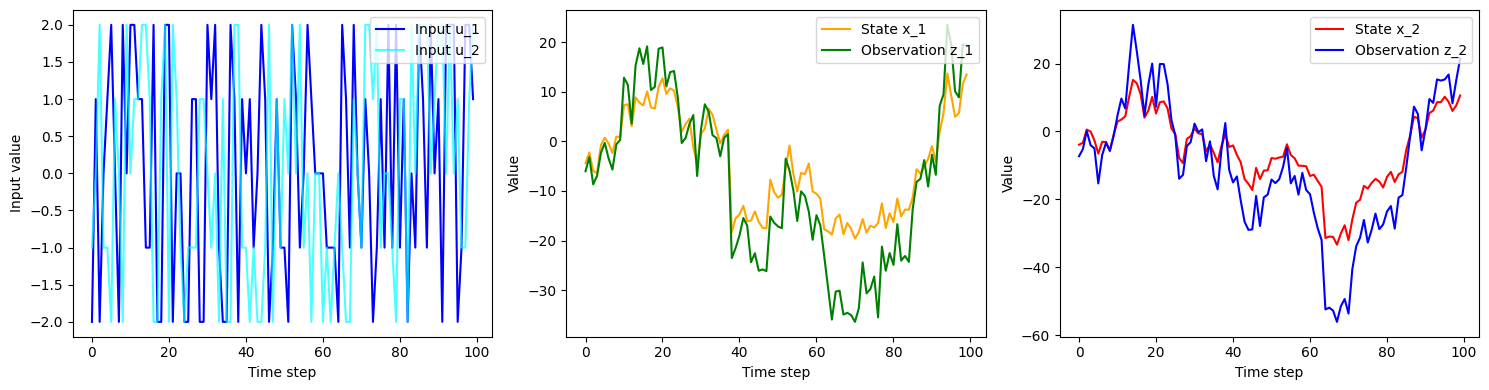

In [48]:
import numpy as np
import matplotlib.pyplot as plt
# random seed
np.random.seed(26)

#  Set sequence length
size = 100
# Dimensions
state_dim = 2
input_dim = 2
obs_dim = 2

# Initial state
x0 = np.array([0.5, -0.3])

uk = np.random.choice(np.arange(-2, 3), size=(size, input_dim)) # Random inputs
xk = np.zeros((size, state_dim)) # hidden states
zk = np.zeros((size, obs_dim)) # observations

# System matrices
A = np.array([[0.85, 0.1],
              [0.05, 0.9]])
B = np.array([[1.5, 0.2],
              [0.1, 1.8]])
C = np.array([[1.2, 0.4],
              [0.3, 1.5]])
D = np.array([[0.5, -0.3],
              [-0.2, 0.7]])

# Covariance matrices for process and measurement noise
Q = np.diag([2.0, 1.5])
R = np.diag([3.0, 2.5])


process_noises = []
measurement_noises = []

for i, u in enumerate(uk):
    # Non-Gaussian process noise: Student's t-distribution (heavy tails)
    # df=3 gives heavy tails, scale to match Q covariance
    process_noise = np.random.standard_t(df=3, size=state_dim) * np.sqrt(np.diag(Q))
    
    process_noises.append(process_noise)
    
    # Nonlinear state transition: bounded nonlinear function (sin)
    if i == 0:
        xk[i] = A @ x0 + B @ u + 0.5 * np.sin(x0) + process_noise
    else:
        xk[i] = A @ xk[i - 1] + B @ u + 0.5 * np.sin(xk[i - 1]) + process_noise

    # Non-Gaussian measurement noise: Student's t-distribution (heavy tails)
    measurement_noise = np.random.standard_t(df=3, size=obs_dim) * np.sqrt(np.diag(R))
    
    measurement_noises.append(measurement_noise)
    
    # Nonlinear observation model: bounded nonlinear function (sin)
    zk[i] = C @ xk[i] + D @ u + 0.3 * np.sin(xk[i]) + measurement_noise

process_noises = np.vstack(process_noises)       # (size, 2)
measurement_noises = np.vstack(measurement_noises)  # (size, 2)


plt.figure(figsize=(15, 4))
plt.subplot(1, 3, 1)
plt.plot(uk[:, 0], label='Input u_1', color='blue')
plt.plot(uk[:, 1], label='Input u_2', color='cyan', alpha=0.7)
plt.xlabel('Time step')
plt.ylabel('Input value')
plt.legend(loc='upper right')
plt.subplot(1, 3, 2)
plt.plot(xk[:, 0], label='State x_1', color='orange')
plt.plot(zk[:, 0], label='Observation z_1', color='green')
plt.xlabel('Time step')
plt.ylabel('Value')
plt.legend(loc='upper right')
plt.subplot(1, 3, 3)
plt.plot(xk[:, 1], label='State x_2', color='red')
plt.plot(zk[:, 1], label='Observation z_2', color='blue')
plt.xlabel('Time step')
plt.ylabel('Value')
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

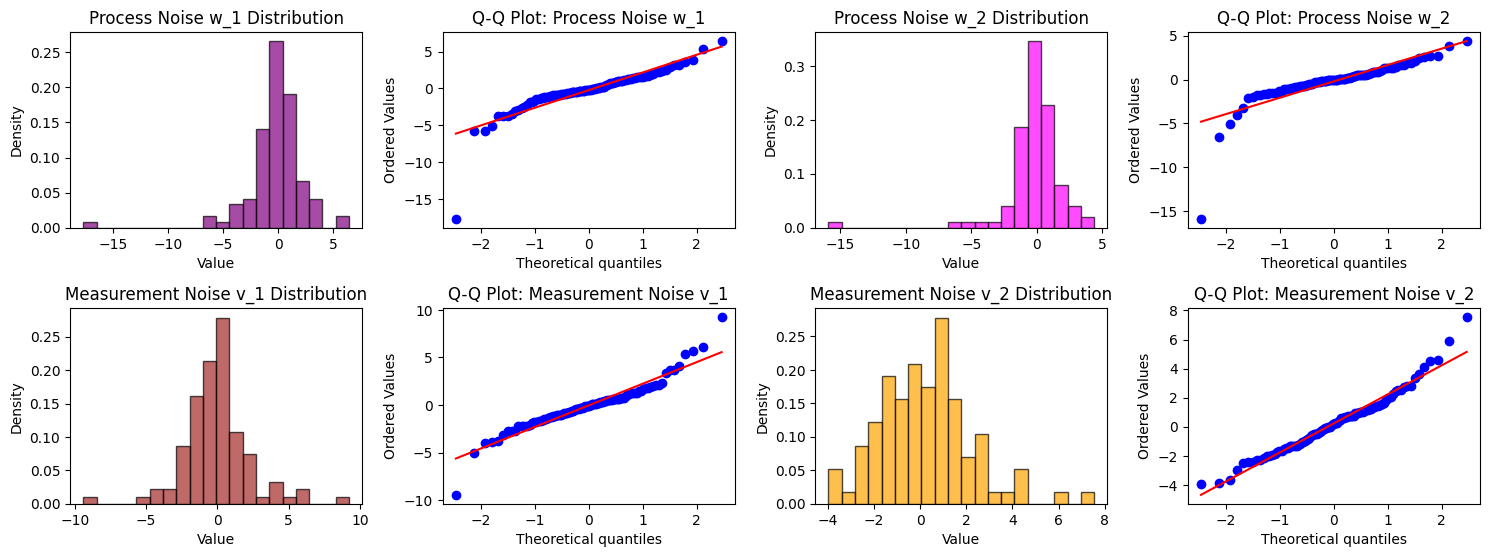

In [49]:
# plot the process and measurement noise
from scipy import stats

plt.figure(figsize=(15, 8))

# Process noise w_1
plt.subplot(3, 4, 1)
plt.hist(process_noises[:, 0], bins=20, density=True, alpha=0.7, color='purple', edgecolor='black')
plt.xlabel('Value')
plt.ylabel('Density')
plt.title('Process Noise w_1 Distribution')

plt.subplot(3, 4, 2)
stats.probplot(process_noises[:, 0], dist="norm", plot=plt)
plt.title('Q-Q Plot: Process Noise w_1')

# Process noise w_2
plt.subplot(3, 4, 3)
plt.hist(process_noises[:, 1], bins=20, density=True, alpha=0.7, color='magenta', edgecolor='black')
plt.xlabel('Value')
plt.ylabel('Density')
plt.title('Process Noise w_2 Distribution')

plt.subplot(3, 4, 4)
stats.probplot(process_noises[:, 1], dist="norm", plot=plt)
plt.title('Q-Q Plot: Process Noise w_2')

# Measurement noise v_1
plt.subplot(3, 4, 5)
plt.hist(measurement_noises[:, 0], bins=20, density=True, alpha=0.7, color='brown', edgecolor='black')
plt.xlabel('Value')
plt.ylabel('Density')
plt.title('Measurement Noise v_1 Distribution')

plt.subplot(3, 4, 6)
stats.probplot(measurement_noises[:, 0], dist="norm", plot=plt)
plt.title('Q-Q Plot: Measurement Noise v_1')

# Measurement noise v_2
plt.subplot(3, 4, 7)
plt.hist(measurement_noises[:, 1], bins=20, density=True, alpha=0.7, color='orange', edgecolor='black')
plt.xlabel('Value')
plt.ylabel('Density')
plt.title('Measurement Noise v_2 Distribution')

plt.subplot(3, 4, 8)
stats.probplot(measurement_noises[:, 1], dist="norm", plot=plt)
plt.title('Q-Q Plot: Measurement Noise v_2')

plt.tight_layout()
plt.show()


1. filtered means/covariances compared to the true means/covariances

In [50]:
# conditon number calculation via SVD
def svd_and_cond(A: np.ndarray):
    Aw = A.astype(np.float32, copy=False) if A.dtype == np.float16 else A
    S = np.linalg.svd(Aw, compute_uv=False)

    sigma_max = np.max(S)
    sigma_min = np.min(S)
    cond_manual = sigma_max / sigma_min
    return cond_manual

def eigvalsh_safe(SigmaX: np.ndarray):
    compute_dtype = np.float32 if SigmaX.dtype == np.float16 else SigmaX.dtype
    SigmaXw = SigmaX.astype(compute_dtype, copy=False)

    eigvals = np.linalg.eigvalsh(SigmaXw)
    eigvals_out = eigvals
    # eigvals_out = eigvals.astype(np.float16) if SigmaX.dtype == np.float16 else eigvals

    return eigvals_out

def inv_safe(S: np.ndarray):
    compute_dtype = np.float32 if S.dtype == np.float16 else S.dtype
    Sw = S.astype(compute_dtype, copy=False)
    inv_S = np.linalg.inv(Sw)
    inv_S_out = inv_S
    # inv_S_out = inv_S.astype(np.float16) if S.dtype == np.float16 else inv_S
    return inv_S_out

In [51]:
# implement the Kalman filter for the multidimensional non-linear and non-Gaussian SSM

# initial model guess
params = {}
params["A"] = np.array([[0.75, 0.05],
                    [0.02, 0.8]])  
params["B"] = np.array([[1.2, 0.1],
                    [0.05, 1.4]])
params["C"] = np.array([[1.0, 0.3],
                    [0.2, 1.2]])
params["D"] = np.array([[0.4, -0.2],
                    [-0.1, 0.5]])

params["Q"] = np.diag([3.5, 2.5])   # sigma W (guess)
params["R"] = np.diag([4.5, 3.5])   # sigma V (guess)


# precision setting
dtype = np.float64  # np.float64 (15～17 digits), np.float32 (6~8 digits)， np.float16 (3~4 digits)
for k in ["A", "B", "C", "D", "Q", "R"]:
    params[k] = params[k].astype(dtype)
uk = uk.astype(dtype)
zk = zk.astype(dtype)


time_idx = np.arange(size)
# initial guesses
xhat = np.zeros(state_dim, dtype=dtype)
SigmaX = np.eye(state_dim, dtype=dtype)
xhatstore = np.zeros((size, state_dim), dtype=dtype)
boundstore = np.zeros((size, state_dim), dtype=dtype)
xhatstore[0] = xhat
boundstore[0] = 3 * np.sqrt(np.diag(SigmaX))

xhatstore_std = np.zeros((size, state_dim), dtype=dtype)
boundstore_std = np.zeros((size, state_dim), dtype=dtype)

# Track covariance properties for standard KF
eigenvalues_std = np.zeros((size, state_dim), dtype=dtype)
min_eigenvalues_std = np.zeros(size, dtype=dtype)
symmetry_error_std = np.zeros(size, dtype=dtype)
condition_number_std = np.zeros(size, dtype=dtype)

xhatstore_std[0] = xhat
boundstore_std[0] = 3 * np.sqrt(np.diag(SigmaX))
eigenvalues_std[0] = eigvalsh_safe(SigmaX)
min_eigenvalues_std[0] = np.min(eigenvalues_std[0])
symmetry_error_std[0] = np.max(np.abs(SigmaX - SigmaX.T))
# condition number?
condition_number_std[0] = svd_and_cond(SigmaX)

# execute Kalman filter
for t in range(1, size):
    # KF Step 1a: State estimate time update (prediction)
    xhat_pred = params["A"] @ xhat + params["B"] @ uk[t - 1]
    # KF Step 1b: Error covariance time update
    SigmaX_pred = params["A"] @ SigmaX @ params["A"].T + params["Q"]
    # KF Step 1c: Estimate system output
    zhat = params["C"] @ xhat_pred + params["D"] @ uk[t]

    # KF Step 2a: Compute Kalman gain
    S = params["C"] @ SigmaX_pred @ params["C"].T + params["R"]
    L = SigmaX_pred @ params["C"].T @ inv_safe(S)
    # KF Step 2b: State estimate measurement update
    xhat = xhat_pred + L @ (zk[t] - zhat)
    # KF Step 2c: Error covariance measurement update
    SigmaX = (np.eye(state_dim) - L @ params["C"]) @ SigmaX_pred

    # Track properties
    eigenvalues_std[t] = eigvalsh_safe(SigmaX)
    min_eigenvalues_std[t] = np.min(eigenvalues_std[t])
    symmetry_error_std[t] = np.linalg.norm(SigmaX - SigmaX.T, ord='fro')
    # condition_number_std[t] = np.linalg.cond(SigmaX, 2)
    condition_number_std[t] = svd_and_cond(SigmaX)

    xhatstore[t] = xhat
    boundstore[t] = 3 * np.sqrt(np.diag(SigmaX))
    # boundstore[t] = 3 * np.sqrt(np.clip(np.diag(SigmaX), a_min=0.0, a_max=None))



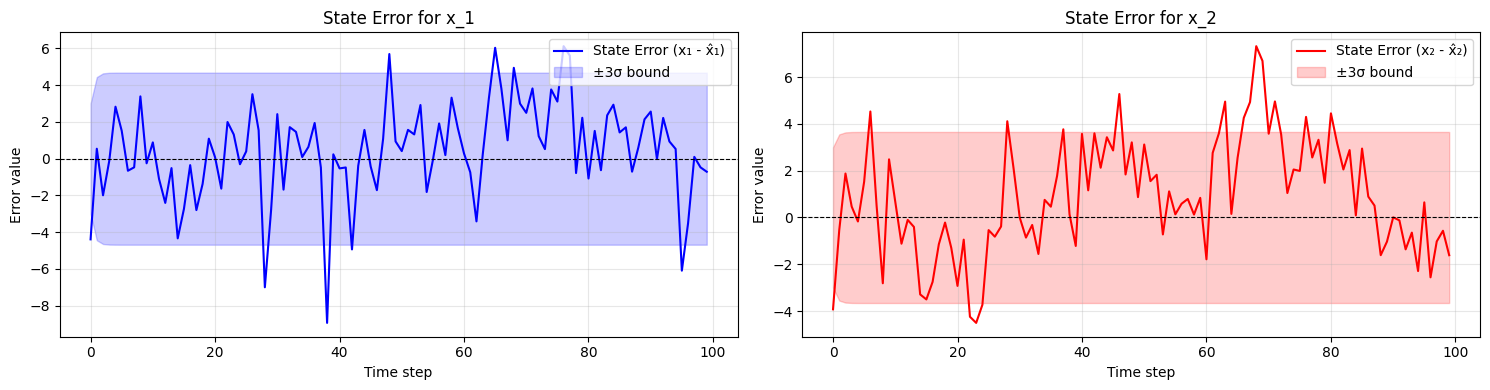

Percentage of x_1 errors within ±3σ bounds: 90.0%
Percentage of x_2 errors within ±3σ bounds: 84.0%


In [52]:
# State error with bounds
xerrKF = xk - xhatstore

fig, axs = plt.subplots(1, 2, figsize=(15, 4))
axs[0].plot(time_idx, xerrKF[:, 0], label='State Error (x₁ - x̂₁)', color='blue')
axs[0].fill_between(time_idx,
                    -boundstore[:, 0],
                    boundstore[:, 0],
                    color='blue', alpha=0.2, label='±3σ bound')
axs[0].axhline(y=0, color='black', linestyle='--', linewidth=0.8)
axs[0].set_xlabel('Time step')
axs[0].set_ylabel('Error value')
axs[0].set_title('State Error for x_1')
axs[0].legend(loc='upper right')
axs[0].grid(True, alpha=0.3)

axs[1].plot(time_idx, xerrKF[:, 1], label='State Error (x₂ - x̂₂)', color='red')
axs[1].fill_between(time_idx,
                    -boundstore[:, 1],
                    boundstore[:, 1],
                    color='red', alpha=0.2, label='±3σ bound')
axs[1].axhline(y=0, color='black', linestyle='--', linewidth=0.8)
axs[1].set_xlabel('Time step')
axs[1].set_ylabel('Error value')
axs[1].set_title('State Error for x_2')
axs[1].legend(loc='upper right')
axs[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Calculate percentage of errors within bounds
within_bounds_x1 = np.sum(np.abs(xerrKF[:, 0]) <= boundstore[:, 0]) / size * 100
within_bounds_x2 = np.sum(np.abs(xerrKF[:, 1]) <= boundstore[:, 1]) / size * 100
print(f"Percentage of x_1 errors within ±3σ bounds: {within_bounds_x1:.1f}%")
print(f"Percentage of x_2 errors within ±3σ bounds: {within_bounds_x2:.1f}%")

# EKF implementation

In [53]:
import time
import tracemalloc

# implement the Extended Kalman filter for the multidimensional non-linear and non-Gaussian SSM

# initial model guess
params = {}
params["A"] = np.array([[0.75, 0.05],
                    [0.02, 0.8]])  
params["B"] = np.array([[1.2, 0.1],
                    [0.05, 1.4]])
params["C"] = np.array([[1.0, 0.3],
                    [0.2, 1.2]])
params["D"] = np.array([[0.4, -0.2],
                    [-0.1, 0.5]])

params["Q"] = np.diag([3.5, 2.5])   # sigma W (guess)
params["R"] = np.diag([4.5, 3.5])   # sigma V (guess)


k1_f = 0.3     # was 0.3
k1_h = 0.3     # was 0.5

# precision setting
dtype = np.float64  # np.float64 (15～17 digits), np.float32 (6~8 digits)， np.float16 (3~4 digits)
for k in ["A", "B", "C", "D", "Q", "R"]:
    params[k] = params[k].astype(dtype)
uk = uk.astype(dtype)
zk = zk.astype(dtype)

state_dim = params["A"].shape[0]
obs_dim = params["R"].shape[0]

# time index and initial guesses
time_idx = np.arange(size)
xhat = np.zeros(state_dim, dtype=dtype)
SigmaX = np.eye(state_dim, dtype=dtype)

xhatstore = np.zeros((size, state_dim), dtype=dtype)
boundstore = np.zeros((size, state_dim), dtype=dtype)
xhatstore[0] = xhat
boundstore[0] = 3 * np.sqrt(np.diag(SigmaX))

# Start memory tracking
tracemalloc.start()
start_time = time.time()

# execute EKF with first-order Taylor approximation
for t in range(1, size):
    # EKF Step 0: Compute Jacobian using first-order approximation
    # Approximate: g(x) ≈ k*x 
    # Full Jacobian: F = A + k1_f*I
    F = params["A"] + k1_f * np.eye(state_dim)
    
    # Step 1a: State estimate time update (prediction)
    # Using linear approximation: f(x,u) = A*x + B*u + k1_f*x
    # This simplifies to: f(x,u) = (A + k1_f*I)*x + B*u
    xhat_pred = (params["A"] + k1_f * np.eye(state_dim)) @ xhat + params["B"] @ uk[t - 1]

    # Step 1b: Error covariance time update
    # Linearized using constant Jacobian F
    SigmaX_pred = F @ SigmaX @ F.T + params["Q"]

    # Step 1c: Output estimate
    # Using linear approximation: h(x,u) = C*x + D*u + k1_h*x
    # This simplifies to: h(x,u) = (C + k1_h*I)*x + D*u
    zhat = (params["C"] + k1_h * np.eye(state_dim)) @ xhat_pred + params["D"] @ uk[t]

    # Step 2a: Estimator gain matrix
    # Jacobian for measurement: H = C + k1_h*I
    H = params["C"] + k1_h * np.eye(state_dim)
    S = H @ SigmaX_pred @ H.T + params["R"]
    L = SigmaX_pred @ H.T @ inv_safe(S)

    # Step 2b: State estimate measurement update
    r = zk[t] - zhat  # residual (innovation)
    xhat = xhat_pred + L @ r

    # Step 2c: Error covariance measurement update
    SigmaX = SigmaX_pred - L @ S @ L.T

    # store
    xhatstore[t] = xhat
    boundstore[t] = 3 * np.sqrt(np.diag(SigmaX))

# Stop timing and memory tracking
end_time = time.time()
current_memory, peak_memory = tracemalloc.get_traced_memory()
tracemalloc.stop()

# Report performance metrics
runtime = end_time - start_time
print("Done!")
print(f"\n{'='*50}")
print(f"EKF Performance Metrics:")
print(f"{'='*50}")
print(f"Runtime:        {runtime:.4f} seconds ({runtime*1000:.2f} ms)")
print(f"Peak Memory:    {peak_memory / 1024**2:.2f} MB")
print(f"Current Memory: {current_memory / 1024**2:.2f} MB")
print(f"{'='*50}")

Done!

EKF Performance Metrics:
Runtime:        0.0213 seconds (21.26 ms)
Peak Memory:    0.04 MB
Current Memory: 0.01 MB


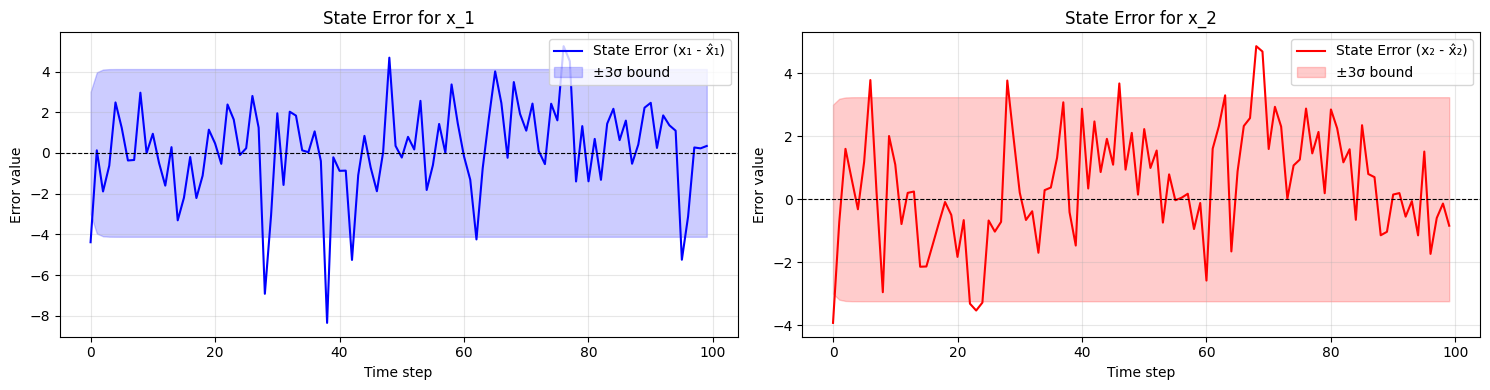

Percentage of x_1 errors within ±3σ bounds: 91.0%
Percentage of x_2 errors within ±3σ bounds: 90.0%


In [54]:
# State error with bounds
xerrEKF = xk - xhatstore

fig, axs = plt.subplots(1, 2, figsize=(15, 4))
axs[0].plot(time_idx, xerrEKF[:, 0], label='State Error (x₁ - x̂₁)', color='blue')
axs[0].fill_between(time_idx,
                    -boundstore[:, 0],
                    boundstore[:, 0],
                    color='blue', alpha=0.2, label='±3σ bound')
axs[0].axhline(y=0, color='black', linestyle='--', linewidth=0.8)
axs[0].set_xlabel('Time step')
axs[0].set_ylabel('Error value')
axs[0].set_title('State Error for x_1')
axs[0].legend(loc='upper right')
axs[0].grid(True, alpha=0.3)

axs[1].plot(time_idx, xerrEKF[:, 1], label='State Error (x₂ - x̂₂)', color='red')
axs[1].fill_between(time_idx,
                    -boundstore[:, 1],
                    boundstore[:, 1],
                    color='red', alpha=0.2, label='±3σ bound')
axs[1].axhline(y=0, color='black', linestyle='--', linewidth=0.8)
axs[1].set_xlabel('Time step')
axs[1].set_ylabel('Error value')
axs[1].set_title('State Error for x_2')
axs[1].legend(loc='upper right')
axs[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Calculate percentage of errors within bounds
within_bounds_x1 = np.sum(np.abs(xerrEKF[:, 0]) <= boundstore[:, 0]) / size * 100
within_bounds_x2 = np.sum(np.abs(xerrEKF[:, 1]) <= boundstore[:, 1]) / size * 100
print(f"Percentage of x_1 errors within ±3σ bounds: {within_bounds_x1:.1f}%")
print(f"Percentage of x_2 errors within ±3σ bounds: {within_bounds_x2:.1f}%")

In [55]:
print("\nEKF results:")
rmse_x1 = np.sqrt(np.mean((xk[:, 0] - xhatstore[:, 0]) ** 2))
rmse_x2 = np.sqrt(np.mean((xk[:, 1] - xhatstore[:, 1]) ** 2))
print(f"RMSE (x_1) = {rmse_x1:5.3f}")
print(f"RMSE (x_2) = {rmse_x2:5.3f}")


EKF results:
RMSE (x_1) = 2.257
RMSE (x_2) = 1.848


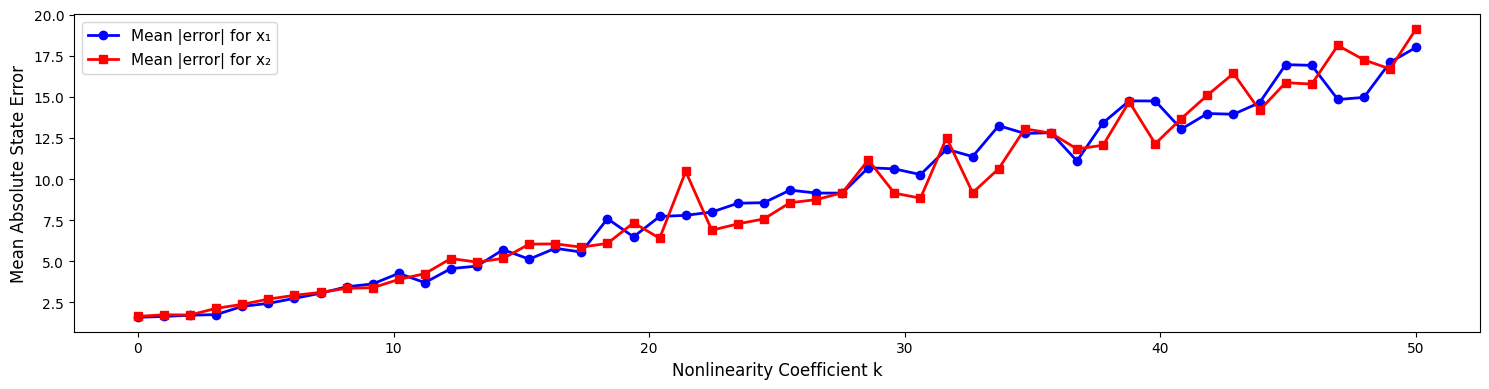

Nonlinearity range: 0.00 to 50.00
Mean error (x₁) increase: 1.5998 → 18.0030
Mean error (x₂) increase: 1.6561 → 19.1243


In [56]:
# linearization accuracy limits
# Test EKF performance under varying nonlinearity strength

# Range of nonlinearity coefficients to test
nonlinearity_range = np.linspace(0.0, 50.0, 50)  # From 0 (linear) to 50.0 (strong nonlinearity)
mean_errors_x1 = []
mean_errors_x2 = []

for k_nonlinear in nonlinearity_range:
    # Generate data with varying nonlinearity
    np.random.seed(26)
    xk_test = np.zeros((size, state_dim))
    zk_test = np.zeros((size, obs_dim))
    
    for i, u in enumerate(uk):
        process_noise = np.random.standard_t(df=3, size=state_dim) * np.sqrt(np.diag(Q))
        
        if i == 0:
            xk_test[i] = A @ x0 + B @ u + k_nonlinear * np.sin(x0) + process_noise
        else:
            xk_test[i] = A @ xk_test[i - 1] + B @ u + k_nonlinear * np.sin(xk_test[i - 1]) + process_noise
        
        measurement_noise = np.random.standard_t(df=3, size=obs_dim) * np.sqrt(np.diag(R))
        zk_test[i] = C @ xk_test[i] + D @ u + k_nonlinear * np.sin(xk_test[i]) + measurement_noise
    
    # Run EKF
    xhat_ekf = np.zeros(state_dim, dtype=dtype)
    SigmaX_ekf = np.eye(state_dim, dtype=dtype)
    xhatstore_ekf = np.zeros((size, state_dim), dtype=dtype)
    xhatstore_ekf[0] = xhat_ekf
    
    for t in range(1, size):
        F = params["A"] + k1_f * np.eye(state_dim)
        xhat_pred = (params["A"] + k1_f * np.eye(state_dim)) @ xhat_ekf + params["B"] @ uk[t - 1]
        SigmaX_pred = F @ SigmaX_ekf @ F.T + params["Q"]
        zhat = (params["C"] + k1_h * np.eye(state_dim)) @ xhat_pred + params["D"] @ uk[t]
        H = params["C"] + k1_h * np.eye(state_dim)
        S = H @ SigmaX_pred @ H.T + params["R"]
        L = SigmaX_pred @ H.T @ inv_safe(S)
        r = zk_test[t] - zhat
        xhat_ekf = xhat_pred + L @ r
        SigmaX_ekf = SigmaX_pred - L @ S @ L.T
        xhatstore_ekf[t] = xhat_ekf
    
    # Calculate mean absolute error
    error = np.abs(xk_test - xhatstore_ekf)
    mean_errors_x1.append(np.mean(error[:, 0]))
    mean_errors_x2.append(np.mean(error[:, 1]))

# Plot results
fig, ax = plt.subplots(1, 1, figsize=(15, 4))
ax.plot(nonlinearity_range, mean_errors_x1, 'o-', label='Mean |error| for x₁', color='blue', linewidth=2)
ax.plot(nonlinearity_range, mean_errors_x2, 's-', label='Mean |error| for x₂', color='red', linewidth=2)
ax.set_xlabel('Nonlinearity Coefficient k', fontsize=12)
ax.set_ylabel('Mean Absolute State Error', fontsize=12)
# ax.set_title('EKF Linearization Error vs. Nonlinearity Strength', fontsize=14)
ax.legend(loc='upper left', fontsize=11)
# ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Nonlinearity range: {nonlinearity_range[0]:.2f} to {nonlinearity_range[-1]:.2f}")
print(f"Mean error (x₁) increase: {mean_errors_x1[0]:.4f} → {mean_errors_x1[-1]:.4f}")
print(f"Mean error (x₂) increase: {mean_errors_x2[0]:.4f} → {mean_errors_x2[-1]:.4f}")

# UKF implemenatation

In [57]:
import time
import tracemalloc

# Initial state and covariance
x0 = np.zeros(state_dim, dtype=dtype)
S0 = np.eye(state_dim, dtype=dtype)

# Nonlinearity coefficients
k_process = 0.25
k_measure = 0.85

# Initialize UKF
xhat = x0
SigmaX = S0
xhatstore = np.zeros((size, state_dim), dtype=dtype)
boundstore = np.zeros((size, state_dim), dtype=dtype)
xhatstore[0] = xhat
boundstore[0] = 3 * np.sqrt(np.diag(SigmaX))

# UKF parameters
alpha = 1.0
kappa = 0.0
beta = 2.0

# Augmented state dimension
n = state_dim
nw = state_dim
nv = obs_dim
na = state_dim + nw + nv
lamb = alpha**2 * (na + kappa) - na
h = np.sqrt(na + lamb)

# Weights
Wm = np.concatenate([np.array([lamb / (na + lamb)]), 
                     np.full(2 * na, 1 / (2 * (na + lamb)))])
Wc = np.concatenate([np.array([lamb / (na + lamb) + (1 - alpha**2 + beta)]),
                     np.full(2 * na, 1 / (2 * (na + lamb)))])

# Noise covariance
Snoise = np.block([[np.linalg.cholesky(params["Q"]), np.zeros((nw, nv))],
                   [np.zeros((nv, nw)), np.linalg.cholesky(params["R"])]])

# Define state equation
def stateEqn(xold, u, xnoise):
    # Linear part
    xnew = params["A"] @ xold + params["B"] @ u
    # Nonlinear part
    xnew = xnew + k_process * np.sin(xold)
    # Add noise
    xnew = xnew + xnoise
    return xnew

# Define measurement equation
def outputEqn(x, u, znoise):
    # Linear part 
    z = params["C"] @ x + params["D"] @ u
    # Nonlinear part 
    z = z + k_measure * np.sin(x)
    # Add noise
    z = z + znoise
    return z

# Start performance tracking
tracemalloc.start()
start_time = time.time()

# execute UKF
for t in range(1, size):
    # Step 1a: State estimate time update
    # Step 1a-1: Create augmented SigmaX and xhat
    sigmaXa = np.linalg.cholesky(SigmaX)
    sigmaXa = np.block([[sigmaXa, np.zeros((n, nw + nv))],
                        [np.zeros((nw + nv, n)), Snoise]])
    xhata = np.concatenate([xhat, np.zeros(nw + nv)])
    
    # Step 1a-2: Calculate SigmaX points
    Xa = np.zeros((na, 2 * na + 1), dtype=dtype)
    Xa[:, 0] = xhata
    for i in range(na):
        Xa[:, i + 1] = xhata + h * sigmaXa[:, i]
        Xa[:, na + i + 1] = xhata - h * sigmaXa[:, i]
    
    # Step 1a-3: Time update from last iteration until now
    Xx = np.zeros((n, 2 * na + 1), dtype=dtype)
    for i in range(2 * na + 1):
        xold = Xa[:n, i]
        xnoise = Xa[n:n+nw, i]
        Xx[:, i] = stateEqn(xold, uk[t - 1], xnoise)
    
    xhat = Xx @ Wm
    
    # Step 1b: Error covariance time update
    Xs = Xx - xhat[:, np.newaxis]
    SigmaX = Xs @ np.diag(Wc) @ Xs.T
    
    # Step 1c: Output estimate
    Z = np.zeros((obs_dim, 2 * na + 1), dtype=dtype)
    for i in range(2 * na + 1):
        znoise = Xa[n+nw:, i]
        Z[:, i] = outputEqn(Xx[:, i], uk[t], znoise)
    
    zhat = Z @ Wm
    
    # Step 2a: Estimator gain matrix
    Zs = Z - zhat[:, np.newaxis]
    SigmaXZ = Xs @ np.diag(Wc) @ Zs.T
    SigmaZ = Zs @ np.diag(Wc) @ Zs.T
    L = SigmaXZ @ inv_safe(SigmaZ)
    
    # Step 2b: State estimate measurement update
    r = zk[t] - zhat  # residual (innovation)
    xhat = xhat + L @ r
    
    # Step 2c: Error covariance measurement update
    SigmaX = SigmaX - L @ SigmaZ @ L.T

    xhatstore[t] = xhat
    boundstore[t] = 3 * np.sqrt(np.diag(SigmaX))

# Stop performance tracking
end_time = time.time()
current_memory, peak_memory = tracemalloc.get_traced_memory()
tracemalloc.stop()

# Print performance metrics
runtime = end_time - start_time
print("\n" + "="*50)
print("UKF Performance Metrics:")
print("="*50)
print(f"Runtime: {runtime:.4f} seconds ({runtime*1000:.2f} ms)")
print(f"Peak Memory Usage: {peak_memory / 1024**2:.2f} MB")
print(f"Current Memory Usage: {current_memory / 1024**2:.2f} MB")
print("="*50)


UKF Performance Metrics:
Runtime: 0.1407 seconds (140.73 ms)
Peak Memory Usage: 0.06 MB
Current Memory Usage: 0.01 MB


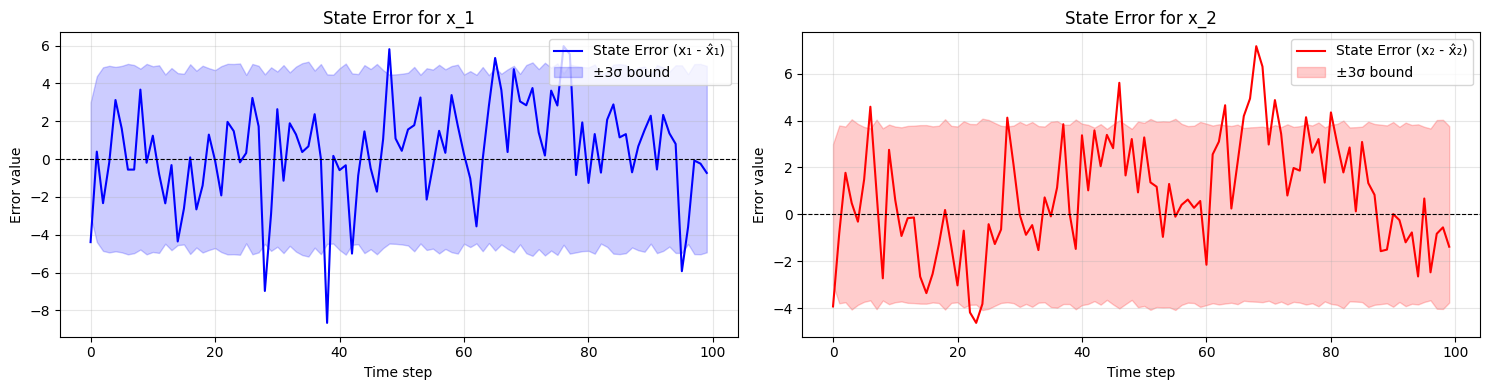

Percentage of x_1 errors within ±3σ bounds: 91.0%
Percentage of x_2 errors within ±3σ bounds: 85.0%


In [58]:
# State error with bounds
xerrUKF = xk - xhatstore

fig, axs = plt.subplots(1, 2, figsize=(15, 4))
axs[0].plot(time_idx, xerrUKF[:, 0], label='State Error (x₁ - x̂₁)', color='blue')
axs[0].fill_between(time_idx,
                    -boundstore[:, 0],
                    boundstore[:, 0],
                    color='blue', alpha=0.2, label='±3σ bound')
axs[0].axhline(y=0, color='black', linestyle='--', linewidth=0.8)
axs[0].set_xlabel('Time step')
axs[0].set_ylabel('Error value')
axs[0].set_title('State Error for x_1')
axs[0].legend(loc='upper right')
axs[0].grid(True, alpha=0.3)

axs[1].plot(time_idx, xerrUKF[:, 1], label='State Error (x₂ - x̂₂)', color='red')
axs[1].fill_between(time_idx,
                    -boundstore[:, 1],
                    boundstore[:, 1],
                    color='red', alpha=0.2, label='±3σ bound')
axs[1].axhline(y=0, color='black', linestyle='--', linewidth=0.8)
axs[1].set_xlabel('Time step')
axs[1].set_ylabel('Error value')
axs[1].set_title('State Error for x_2')
axs[1].legend(loc='upper right')
axs[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Calculate percentage of errors within bounds
within_bounds_x1 = np.sum(np.abs(xerrUKF[:, 0]) <= boundstore[:, 0]) / size * 100
within_bounds_x2 = np.sum(np.abs(xerrUKF[:, 1]) <= boundstore[:, 1]) / size * 100
print(f"Percentage of x_1 errors within ±3σ bounds: {within_bounds_x1:.1f}%")
print(f"Percentage of x_2 errors within ±3σ bounds: {within_bounds_x2:.1f}%")

In [59]:
print("\nUKF results:")
rmse_x1 = np.sqrt(np.mean((xk[:, 0] - xhatstore[:, 0]) ** 2))
rmse_x2 = np.sqrt(np.mean((xk[:, 1] - xhatstore[:, 1]) ** 2))
print(f"RMSE (x_1) = {rmse_x1:5.3f}")
print(f"RMSE (x_2) = {rmse_x2:5.3f}")


UKF results:
RMSE (x_1) = 2.595
RMSE (x_2) = 2.554


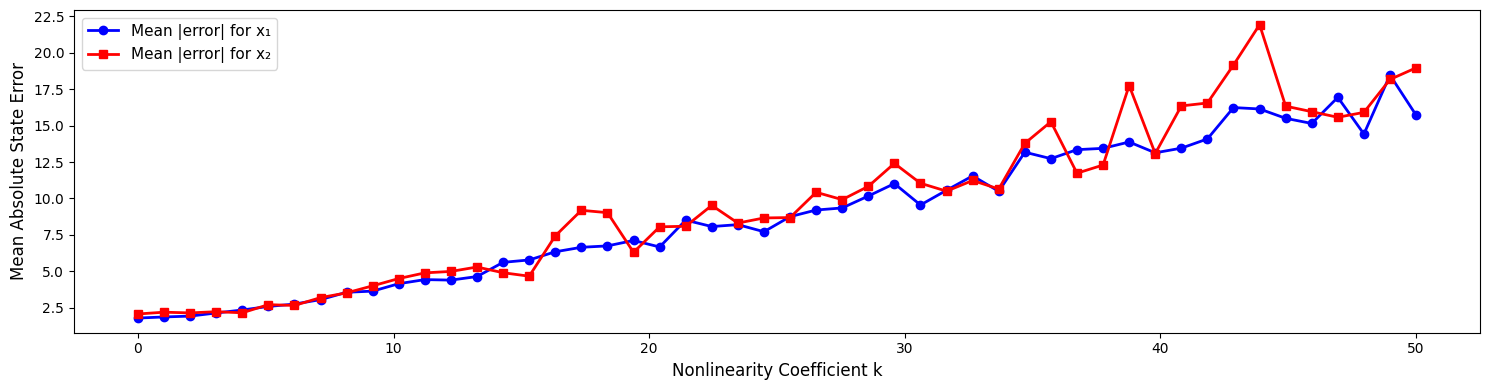

Nonlinearity range: 0.00 to 50.00
Mean error (x₁) increase: 1.7783 → 15.7196
Mean error (x₂) increase: 2.0585 → 18.9709


In [60]:
# Sigma point failures under strong nonlinearity

# Range of nonlinearity coefficients to test
nonlinearity_range_ukf = np.linspace(0.0, 50.0, 50)  # From 0 (linear) to 50.0 (strong nonlinearity)
mean_errors_ukf_x1 = []
mean_errors_ukf_x2 = []

# UKF parameters (same as used in the main UKF implementation)
alpha_test = 1.0
beta_test = 3
kappa_test = 0.0
k_process_test = 0.25
k_measure_test = 0.85

for k_nonlinear in nonlinearity_range_ukf:
    # Generate data with varying nonlinearity
    np.random.seed(26)
    xk_test = np.zeros((size, state_dim))
    zk_test = np.zeros((size, obs_dim))
    
    for i, u in enumerate(uk):
        process_noise = np.random.standard_t(df=3, size=state_dim) * np.sqrt(np.diag(Q))
        
        if i == 0:
            xk_test[i] = A @ x0 + B @ u + k_nonlinear * np.sin(x0) + process_noise
        else:
            xk_test[i] = A @ xk_test[i - 1] + B @ u + k_nonlinear * np.sin(xk_test[i - 1]) + process_noise
        
        measurement_noise = np.random.standard_t(df=3, size=obs_dim) * np.sqrt(np.diag(R))
        zk_test[i] = C @ xk_test[i] + D @ u + k_nonlinear * np.sin(xk_test[i]) + measurement_noise
    
    # Run UKF
    xhat_ukf = np.zeros(state_dim, dtype=dtype)
    SigmaX_ukf = np.eye(state_dim, dtype=dtype)
    xhatstore_ukf = np.zeros((size, state_dim), dtype=dtype)
    xhatstore_ukf[0] = xhat_ukf
    
    # UKF setup
    n_test = state_dim
    nw_test = state_dim
    nv_test = obs_dim
    na_test = n_test + nw_test + nv_test
    lambda_param_test = alpha_test**2 * (na_test + kappa_test) - na_test
    h_test = np.sqrt(na_test + lambda_param_test)
    
    # Weights
    Wm_test = np.zeros(2 * na_test + 1, dtype=dtype)
    Wc_test = np.zeros(2 * na_test + 1, dtype=dtype)
    Wm_test[0] = lambda_param_test / (na_test + lambda_param_test)
    Wc_test[0] = Wm_test[0] + (1 - alpha_test**2 + beta_test)
    for i in range(1, 2 * na_test + 1):
        Wm_test[i] = 1.0 / (2.0 * (na_test + lambda_param_test))
        Wc_test[i] = Wm_test[i]
    
    Snoise_test = np.block([[np.linalg.cholesky(params["Q"]), np.zeros((nw_test, nv_test))],
                            [np.zeros((nv_test, nw_test)), np.linalg.cholesky(params["R"])]])
    
    # Define state and measurement equations for testing
    def stateEqn_test(xold, u, xnoise):
        xnew = params["A"] @ xold + params["B"] @ u
        xnew = xnew + k_process_test * np.sin(xold)
        xnew = xnew + xnoise
        return xnew
    
    def outputEqn_test(x, u, znoise):
        z = params["C"] @ x + params["D"] @ u
        z = z + k_measure_test * np.sin(x)
        z = z + znoise
        return z
    
    # Run UKF iterations
    for t in range(1, size):
        # Step 1a-1: Create augmented SigmaX and xhat
        sigmaXa_test = np.linalg.cholesky(SigmaX_ukf)
        sigmaXa_test = np.block([[sigmaXa_test, np.zeros((n_test, nw_test + nv_test))],
                                  [np.zeros((nw_test + nv_test, n_test)), Snoise_test]])
        xhata_test = np.concatenate([xhat_ukf, np.zeros(nw_test + nv_test)])
        
        # Step 1a-2: Calculate sigma points
        Xa_test = np.zeros((na_test, 2 * na_test + 1), dtype=dtype)
        Xa_test[:, 0] = xhata_test
        for i in range(na_test):
            Xa_test[:, i + 1] = xhata_test + h_test * sigmaXa_test[:, i]
            Xa_test[:, na_test + i + 1] = xhata_test - h_test * sigmaXa_test[:, i]
        
        # Step 1a-3: Time update
        Xx_test = np.zeros((n_test, 2 * na_test + 1), dtype=dtype)
        for i in range(2 * na_test + 1):
            xold = Xa_test[:n_test, i]
            xnoise = Xa_test[n_test:n_test+nw_test, i]
            Xx_test[:, i] = stateEqn_test(xold, uk[t - 1], xnoise)
        
        xhat_ukf = Xx_test @ Wm_test
        
        # Step 1b: Error covariance time update
        Xs_test = Xx_test - xhat_ukf[:, np.newaxis]
        SigmaX_ukf = Xs_test @ np.diag(Wc_test) @ Xs_test.T
        
        # Step 1c: Output estimate
        Z_test = np.zeros((obs_dim, 2 * na_test + 1), dtype=dtype)
        for i in range(2 * na_test + 1):
            znoise = Xa_test[n_test+nw_test:, i]
            Z_test[:, i] = outputEqn_test(Xx_test[:, i], uk[t], znoise)
        
        zhat_test = Z_test @ Wm_test
        
        # Step 2a: Estimator gain matrix
        Zs_test = Z_test - zhat_test[:, np.newaxis]
        SigmaXZ_test = Xs_test @ np.diag(Wc_test) @ Zs_test.T
        SigmaZ_test = Zs_test @ np.diag(Wc_test) @ Zs_test.T
        L_test = SigmaXZ_test @ inv_safe(SigmaZ_test)
        
        # Step 2b: State estimate measurement update
        r_test = zk_test[t] - zhat_test
        xhat_ukf = xhat_ukf + L_test @ r_test
        
        # Step 2c: Error covariance measurement update
        SigmaX_ukf = SigmaX_ukf - L_test @ SigmaZ_test @ L_test.T
        
        xhatstore_ukf[t] = xhat_ukf
    
    # Calculate mean absolute error
    error = np.abs(xk_test - xhatstore_ukf)
    mean_errors_ukf_x1.append(np.mean(error[:, 0]))
    mean_errors_ukf_x2.append(np.mean(error[:, 1]))

# Plot results
fig, ax = plt.subplots(1, 1, figsize=(15, 4))
ax.plot(nonlinearity_range_ukf, mean_errors_ukf_x1, 'o-', label='Mean |error| for x₁', color='blue', linewidth=2)
ax.plot(nonlinearity_range_ukf, mean_errors_ukf_x2, 's-', label='Mean |error| for x₂', color='red', linewidth=2)
ax.set_xlabel('Nonlinearity Coefficient k', fontsize=12)
ax.set_ylabel('Mean Absolute State Error', fontsize=12)
# ax.set_title('UKF Sigma Point Performance vs. Nonlinearity Strength', fontsize=14)
ax.legend(loc='upper left', fontsize=11)
# ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Nonlinearity range: {nonlinearity_range_ukf[0]:.2f} to {nonlinearity_range_ukf[-1]:.2f}")
print(f"Mean error (x₁) increase: {mean_errors_ukf_x1[0]:.4f} → {mean_errors_ukf_x1[-1]:.4f}")
print(f"Mean error (x₂) increase: {mean_errors_ukf_x2[0]:.4f} → {mean_errors_ukf_x2[-1]:.4f}")

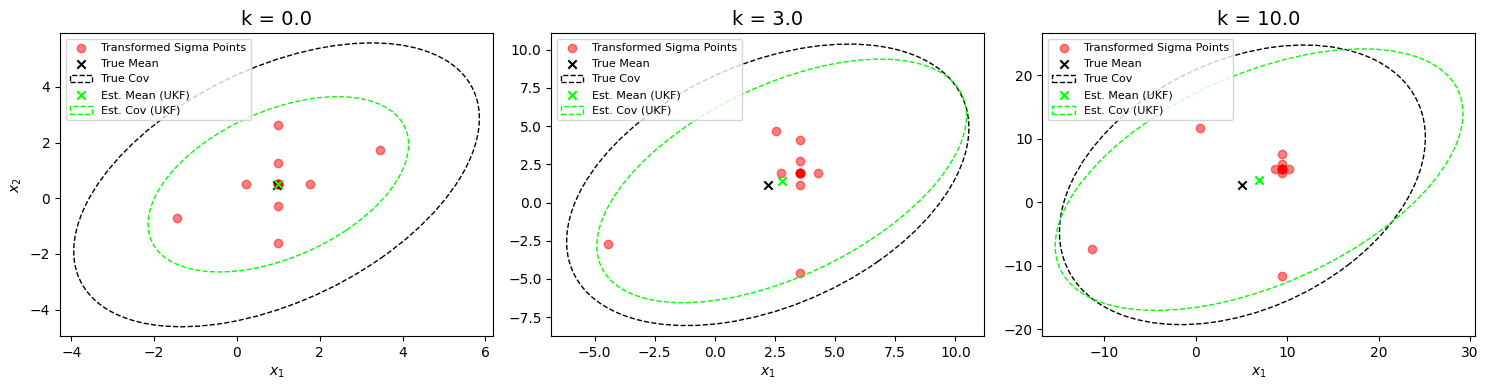

In [61]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
import matplotlib.transforms as transforms

# --- Helper function: for plotting covariance ellipses ---
# Defaulting to n_std=3.0 as requested
def plot_cov_ellipse(mean, cov, ax, n_std=3.0, facecolor='none', **kwargs):
    """
    Plots an n_std covariance ellipse.
    """
    # Handle the edge case of a zero-covariance matrix
    if np.all(np.diag(cov) < 1e-10):
        return None  # Cannot plot ellipse

    # Check and correct for numerical issues with Pearson correlation
    cov_diag_prod = cov[0, 0] * cov[1, 1]
    if cov_diag_prod <= 0:
        if cov[0, 0] < 0 or cov[1, 1] < 0:
            return None  # Non-positive diagonal elements
        pearson = 0
    else:
        pearson = cov[0, 1] / np.sqrt(cov_diag_prod)
        pearson = np.clip(pearson, -1.0, 1.0)  # Clamp value for numerical stability

    ell_radius_x = np.sqrt(1 + pearson)
    ell_radius_y = np.sqrt(1 - pearson)

    if np.isnan(ell_radius_x) or np.isnan(ell_radius_y):
        return None  # Invalid ellipse radii

    ellipse = Ellipse((0, 0),
                      width=ell_radius_x * 2,
                      height=ell_radius_y * 2,
                      facecolor=facecolor,
                      **kwargs)

    # Calculate scaling and rotation
    scale_x = np.sqrt(cov[0, 0]) * n_std
    scale_y = np.sqrt(cov[1, 1]) * n_std

    if np.isnan(scale_x) or np.isnan(scale_y):
        return None

    transf = transforms.Affine2D() \
        .rotate_deg(45) \
        .scale(scale_x, scale_y) \
        .translate(mean[0], mean[1])

    ellipse.set_transform(transf + ax.transData)
    return ax.add_patch(ellipse)

# --- 1. Set Simulation Parameters (as in your script) ---
np.random.seed(26)
dtype = np.float64
state_dim = 2
obs_dim = 2
size = 100  # Time series length (not used in this specific plot, but kept for consistency)
uk = np.zeros((size, 1), dtype=dtype) 
dummy_u = uk[0]  # Define a dummy control input

# System Matrices
A = np.eye(state_dim, dtype=dtype)
B = np.zeros((state_dim, 1), dtype=dtype)
C = np.eye(obs_dim, dtype=dtype)
D = np.zeros((obs_dim, 1), dtype=dtype)
# Noise Covariances
Q = np.eye(state_dim, dtype=dtype) * 0.1
R = np.eye(obs_dim, dtype=dtype) * 0.1

params = {"A": A, "B": B, "C": C, "D": D, "Q": Q, "R": R}

# --- 2. Set UKF Parameters ---
alpha_test = 1.0   # (For visualization, spreads points)
beta_test = 3.0    # (For t-distribution noise, as requested)
kappa_test = 0.0   

# UKF Dimensionality Setup
n_test = state_dim       # State dimension
nw_test = state_dim      # Process noise dimension
nv_test = obs_dim        # Measurement noise dimension
na_test = n_test + nw_test + nv_test  # Augmented state dimension (na_test = 6)
num_sigma_points = 2 * na_test + 1  # Total sigma points (num_sigma_points = 13)

# UKF Weight Calculation
lambda_param_test = alpha_test**2 * (na_test + kappa_test) - na_test
h_test = np.sqrt(na_test + lambda_param_test)  # Scaling factor for sigma points

Wm_test = np.zeros(num_sigma_points, dtype=dtype)  # Weights for mean
Wc_test = np.zeros(num_sigma_points, dtype=dtype)  # Weights for covariance
Wm_test[0] = lambda_param_test / (na_test + lambda_param_test)
Wc_test[0] = Wm_test[0] + (1 - alpha_test**2 + beta_test)
for i in range(1, num_sigma_points):
    Wm_test[i] = 1.0 / (2.0 * (na_test + lambda_param_test))
    Wc_test[i] = Wm_test[i]

# Cholesky factor of augmented noise covariance
Snoise_test = np.block([[np.linalg.cholesky(params["Q"]), np.zeros((nw_test, nv_test))],
                        [np.zeros((nv_test, nw_test)), np.linalg.cholesky(params["R"])]])

# --- 3. Define Nonlinear State Equation (for plotting) ---
def stateEqn_plot(xold, u, xnoise, k_val):
    xnew = params["A"] @ xold + params["B"] @ u
    # The critical nonlinearity we are testing
    xnew = xnew + k_val * np.sin(xold)
    xnew = xnew + xnoise
    return xnew

# --- 4. Monte Carlo "Ground Truth" Generation (runs in background) ---
# We must do this to find the *true* mean/covariance after the
# nonlinear transform of the non-Gaussian t-distribution.
N_samples = 2000  # Number of parallel samples to approximate the "truth"
df = 3            # Degrees of freedom for the t-distribution (from your setup)

# Define the initial belief (mean and covariance)
xhat_initial = np.array([1.0, 0.5], dtype=dtype) 
SigmaX_initial = np.array([[1.0, 0.5], [0.5, 1.0]], dtype=dtype) 

# Generate initial state samples (multivariate t-distribution)
L_state = np.linalg.cholesky(SigmaX_initial)
z_state = np.random.multivariate_normal(np.zeros(state_dim), np.eye(state_dim), N_samples)
u_state = np.random.chisquare(df, N_samples)
t_samples_state = z_state / np.sqrt(u_state / df)[:, np.newaxis]
initial_samples = xhat_initial + t_samples_state @ L_state.T

# Generate process noise samples (independent t-distribution)
t_samples_noise = np.random.standard_t(df, size=(N_samples, nw_test)) * np.sqrt(np.diag(Q))

# --- 5. Plotting Loop ---
k_values_to_plot = [0.0, 3.0, 10.0]  #

# Create one figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
# fig.suptitle('Transformed Points: UKF Estimate vs. True Estimate', fontsize=16, y=1.02)

for ax, k_plot in zip(axes.flat, k_values_to_plot):
    
    # --- A. UKF Sigma Point Transformation ---
    # (Calculate initial augmented sigma points)
    sigmaXa_test = np.linalg.cholesky(SigmaX_initial)
    sigmaXa_test = np.block([[sigmaXa_test, np.zeros((n_test, nw_test + nv_test))],
                              [np.zeros((nw_test + nv_test, n_test)), Snoise_test]])
    xhata_test = np.concatenate([xhat_initial, np.zeros(nw_test + nv_test)])
    
    Xa_test = np.zeros((na_test, num_sigma_points), dtype=dtype)
    Xa_test[:, 0] = xhata_test
    for i in range(na_test):
        Xa_test[:, i + 1] = xhata_test + h_test * sigmaXa_test[:, i]
        Xa_test[:, na_test + i + 1] = xhata_test - h_test * sigmaXa_test[:, i]

    # (Propagate all 13 sigma points through the nonlinear function)
    Xx_test = np.zeros((n_test, num_sigma_points), dtype=dtype)
    for i in range(num_sigma_points):
        xold = Xa_test[:n_test, i]
        xnoise = Xa_test[n_test:n_test+nw_test, i]
        Xx_test[:, i] = stateEqn_plot(xold, dummy_u, xnoise, k_plot)
    
    # --- B. UKF Estimate (from transformed Sigma Points) ---
    xhat_ukf_transformed = Xx_test @ Wm_test  # UKF's estimated mean
    Xs_test = Xx_test - xhat_ukf_transformed[:, np.newaxis]
    SigmaX_ukf_transformed = Xs_test @ np.diag(Wc_test) @ Xs_test.T  # UKF's estimated covariance

    # --- C. "True" Estimate---
    transformed_samples = np.zeros((N_samples, n_test))
    for i in range(N_samples):
        transformed_samples[i] = stateEqn_plot(initial_samples[i], dummy_u, t_samples_noise[i], k_plot)
    
    true_mean_transformed = np.mean(transformed_samples, axis=0)  # "True" mean
    true_cov_transformed = np.cov(transformed_samples, rowvar=False)  # "True" covariance
    
    # --- D. Plotting ---
    # Plot all transformed sigma points (Red)
    ax.scatter(Xx_test[0, :], Xx_test[1, :], 
                c='red', alpha=0.5,label=f'Transformed Sigma Points')  


    # Plot the "True" Estimate (Black)
    ax.scatter(true_mean_transformed[0], true_mean_transformed[1], 
                c='black', marker='x', label='True Mean')
    plot_cov_ellipse(true_mean_transformed, true_cov_transformed, ax=ax, n_std=3.0, 
                     edgecolor='black', linestyle='--', label='True Cov')
    
    # Plot the "UKF" Estimate (Green)
    ax.scatter(xhat_ukf_transformed[0], xhat_ukf_transformed[1], 
                c='lime', marker='x', label='Est. Mean (UKF)')
    plot_cov_ellipse(xhat_ukf_transformed, SigmaX_ukf_transformed, ax=ax, n_std=3.0, 
                     edgecolor='lime', linestyle='--', label='Est. Cov (UKF)')


    ax.set_title(f'k = {k_plot}', fontsize=14)
    ax.set_xlabel('$x_1$')
    if k_plot == 0.0: ax.set_ylabel('$x_2$')
    ax.legend(loc='upper left', fontsize=8)
    # ax.grid(True, alpha=0.3)
    # ax.set_aspect('equal') 

fig.tight_layout()
plt.show()

END